Loading MNIST dataset...
Dataset loaded successfully!

Original Shapes:
X shape: (70000, 784)
y shape: (70000,)


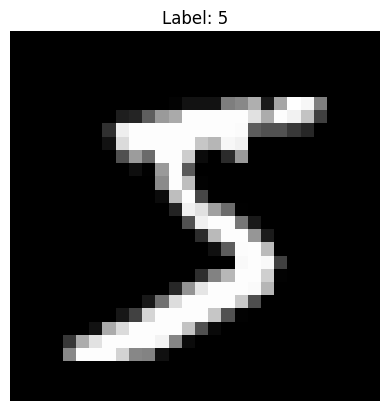


After normalization:
Min pixel value: 0.0
Max pixel value: 1.0

Train/Test Split:
X_train: (56000, 784)
X_test : (14000, 784)
y_train: (56000,)
y_test : (14000,)


In [ ]:
# STEP 1 + STEP 2
# Load MNIST, visualize image, flatten, normalize

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

# STEP 1 — LOAD MNIST DATASET

print("Loading MNIST dataset...")

mnist = fetch_openml('mnist_784', version=1, n_retries=5, delay=2)

# Features (images)
X = mnist.data

# Labels (digits)
y = mnist.target.astype(int)

print("Dataset loaded successfully!")

# CHECK ORIGINAL SHAPES

print("\nOriginal Shapes:")
print("X shape:", X.shape)   # Expected: (70000, 784)
print("y shape:", y.shape)   # Expected: (70000,)

# STEP 2 — VISUALIZE ONE IMAGE

# Select first image
sample_image = X.iloc[0].values

# Reshape back to 28x28 for visualization
sample_image_2d = sample_image.reshape(28, 28)

# Display image
plt.imshow(sample_image_2d, cmap='gray')
plt.title(f"Label: {y[0]}")
plt.axis('off')
plt.show()


# STEP 3 — NORMALIZATION

# Pixel values currently range from 0 to 255
# Normalize to range 0.0 to 1.0 to reduce biasing and overfitting

X = X / 255.0

print("\nAfter normalization:")
print("Min pixel value:", X.min().min())
print("Max pixel value:", X.max().max())

# STEP 4 — TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTrain/Test Split:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

# IMPORTANT UNDERSTANDING

# Each row in X_train:
# shape = (784,)

# Meaning:
# one flattened 28x28 image
# The neural network input layer must therefore contain 784 neurons.


In [ ]:
import random,math

In [ ]:
class Value:
  def __init__(self,data):
    self.data = data

  def __add__(self,other):
    other = other if isinstance(other, Value) else Value(other)
    out=Value(self.data + other.data)
    return out

  def __mul__(self,other):
    other = other if isinstance(other, Value) else Value(other)
    out=Value(self.data * other.data)
    return out

  def __repr__(self):
    return f"Value(data={self.data})"

  # def __sub__(self,other):
  #   other = other if isinstance(other, Value) else Value(other)
  #   out = Value(self.data - other.data)
  #   return out

  def __radd__(self, other): # For `float + Value`
    return self.__add__(other)

  def __rmul__(self, other): # For `float * Value`
    return self.__mul__(other)

  # def __rsub__(self, other): # For `float - Value`
  #   other = other if isinstance(other, Value) else Value(other)
  #   out = Value(other.data - self.data)
  #   return out

  def __min__(self,other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(min(self.data,other.data))
    return out


DEFINING LAYERS OF FEED FORWARD NEURAL NETWORK

In [ ]:
import numpy as np
import random

class Linear:
  def __init__(self, nin, nout):
     self.w = np.array([[np.random.randn()*0.01 for _ in range(nout)] for _ in range(nin)])
     self.b = np.array([[np.random.randn()*0.01 for _ in range(nout)] for _ in range(1)])

  def __call__(self, x):
    act = x @ self.w + self.b
    return act


ADDING NON-LINEARITY

In [ ]:
import numpy as np # Import numpy

def relu(x):
  return np.maximum(0,x)

def tanh(x):
  return  np.exp(2*x)-1/np.exp(2*x)+1
def sigmoid(x):
  return 1/1+np.exp(-x)

CONNECTING LAYERS

In [ ]:
class NeuralNetwork:
  def __init__(self):
    self.l1=Linear(784,128)
    self.l2=Linear(128,64)
    self.l3=Linear(64,32)
    self.l4=Linear(32,10)

  def forward(self,x):
    x=relu(self.l1(x))
    x=relu(self.l2(x))
    x=relu(self.l3(x))
    x=self.l4(x)
    return x


In [ ]:
model = NeuralNetwork()

batch = np.random.randn(32,784)
act = model.forward(batch)
logits= relu(act)
print(logits.shape)
print(logits)

(32, 10)
[[0.         0.         0.         0.         0.00894829 0.
  0.         0.         0.         0.00620507]
 [0.         0.         0.         0.         0.00898592 0.
  0.         0.         0.         0.00627926]
 [0.         0.         0.         0.         0.00894627 0.
  0.         0.         0.         0.00628863]
 [0.         0.         0.         0.         0.00888953 0.
  0.         0.         0.         0.0062453 ]
 [0.         0.         0.         0.         0.00895995 0.
  0.         0.         0.         0.00620548]
 [0.         0.         0.         0.         0.00889182 0.
  0.         0.         0.         0.006241  ]
 [0.         0.         0.         0.         0.00893043 0.
  0.         0.         0.         0.00627987]
 [0.         0.         0.         0.         0.0089538  0.
  0.         0.         0.         0.00633222]
 [0.         0.         0.         0.         0.00893993 0.
  0.         0.         0.         0.0062078 ]
 [0.         0.         0.  

In [ ]:
def softmax(logits):
  out=[]
  for _ in logits:
    probs=np.exp(_)/np.sum(np.exp(_))
    out.append(probs)
  return out
ans=softmax(logits)
ans



[array([0.0998481 , 0.0998481 , 0.0998481 , 0.0998481 , 0.10074558,
        0.0998481 , 0.0998481 , 0.0998481 , 0.0998481 , 0.10046959]),
 array([0.09984698, 0.09984698, 0.09984698, 0.09984698, 0.10074824,
        0.09984698, 0.09984698, 0.09984698, 0.09984698, 0.10047592]),
 array([0.09984728, 0.09984728, 0.09984728, 0.09984728, 0.10074455,
        0.09984728, 0.09984728, 0.09984728, 0.09984728, 0.10047717]),
 array([0.09984829, 0.09984829, 0.09984829, 0.09984829, 0.10073985,
        0.09984829, 0.09984829, 0.09984829, 0.09984829, 0.10047382]),
 array([0.09984798, 0.09984798, 0.09984798, 0.09984798, 0.10074663,
        0.09984798, 0.09984798, 0.09984798, 0.09984798, 0.10046951]),
 array([0.09984831, 0.09984831, 0.09984831, 0.09984831, 0.1007401 ,
        0.09984831, 0.09984831, 0.09984831, 0.09984831, 0.10047341]),
 array([0.09984753, 0.09984753, 0.09984753, 0.09984753, 0.10074321,
        0.09984753, 0.09984753, 0.09984753, 0.09984753, 0.10047653]),
 array([0.09984677, 0.09984677, 0.

In [ ]:
def crossentropy(x,y):
  # x: list of probability arrays (ans from softmax)
  # y: 2D numpy array of true labels (matrix)

  correct_probs = []
  for k in range(len(x)): # Iterate over each sample in the batch
    predicted_probs_for_sample = x[k] # This is a (10,) array of probabilities for one sample
    true_label_for_sample = y[k][0] # y[k] is like array([idx]), so y[k][0] gives the integer index

    # Get the probability for the true class
    prob_of_true_class = predicted_probs_for_sample[true_label_for_sample]
    correct_probs.append(prob_of_true_class)

  # Convert to numpy array for vectorized log operation
  correct_probs_np = np.array(correct_probs)

  # Calculate the negative log likelihood and then the mean
  loss_values = -np.log(correct_probs_np)
  return np.mean(loss_values)

In [ ]:
import numpy as np

# Set print options so Python doesn't truncate/shorten the output
np.set_printoptions(threshold=np.inf, linewidth=150)

# Generate a 32x1 array of random integers between 0 and 8
matrix = np.random.randint(0, 9, size=(32, 1))
x=crossentropy(ans,matrix)
x

np.float64(2.303275753768127)

In [3]:
def gradient():
  pass
